In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import pandas as pd
import pretty_midi as pm
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append('..')
from utils import find_files, get_polyphony_degrees

import itertools
from ast import literal_eval

Prerequisite: prepared ADL Piano MIDI dataset in `../data/apm`... see `../data/README.md` for details.

In [2]:
path_data = '../data/apm/'
available_genres = os.listdir(path_data)

genres_of_interest = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
all([genre in available_genres for genre in genres_of_interest])

True

In [3]:
def get_gaps(midi):
    note_times = [(note.start, note.end) for instrument in midi.instruments for note in instrument.notes]
    note_times.sort()
    gaps = [note_times[0][0]]
    for i in range(1, len(note_times)):
        silence = note_times[i][0] - note_times[i-1][1]
        if silence > 0:
            gaps.append(silence)
    return gaps

def detect_overlapping_notes_in_pretty_midi_note_array(note_events, verbose=False):
    from intervaltree import Interval, IntervalTree
    # Create an interval tree for each unique combination of track, channel, and pitch
    trees = {}
    for note in note_events:
        key = note.pitch
        if key not in trees:
            trees[key] = IntervalTree()
        trees[key].add(Interval(note.start, note.end, note))

    # Find overlaps
    overlaps = []
    for note in note_events:
        key = note.pitch
        overlapping_intervals = trees[key].overlap(note.start, note.end)
        for interval in overlapping_intervals:
            if interval.data != note and interval.begin < note.start:
                overlaps.append((interval.data, note, interval.data.end - note.start))
    
    # Verify overlaps
    for overlap in overlaps:
        note_A, note_B, dur_overlap = overlap
        assert (note_A.start > note_B.start and note_A.start < note_B.end) or (note_B.start > note_A.start and note_B.start < note_A.end)
    
    if verbose:
        print (f'Found {len(overlaps)} overlapping notes.')
    return overlaps

In [5]:
# mean_polyphony = np.mean(polyphonies)
import warnings
warnings.filterwarnings("ignore")

for genre in genres_of_interest:
    path_genre = os.path.join(path_data, genre)
    # if os.path.exists(f'{path_genre}.csv'):
    #     print(f'File already exists: {path_genre}.csv')
    #     continue
    df = pd.DataFrame()#columns=['duration', 'gaps_max', 'gaps_sum', 'path'])
    genre_midi_paths = sorted(find_files(path_genre, '*.mid'))
    for path_midi in tqdm(genre_midi_paths, desc=f'Extracting metadata for genre: {genre}'):
        # skip invalid midi files
        try:
            midi = pm.PrettyMIDI(path_midi)
        except:
            continue
        # extract duration
        duration = midi.get_end_time()
        # extract gaps (silences)
        gaps = get_gaps(midi)
        gaps_max = max(gaps)
        gaps_sum = sum(gaps)
        # extract used instrument programs
        instr_programs = [inst.program for inst in midi.instruments]
        # extract notes, pitch bends and control changes
        num_notes = [len(inst.notes) for inst in midi.instruments]
        num_bends = [len(inst.pitch_bends) for inst in midi.instruments]
        num_ccs = [len(inst.control_changes) for inst in midi.instruments]
        # extract unique control change numbers, pitches and velocities
        uniq_cc_nums = list(np.unique(list(itertools.chain.from_iterable([[cc.number for cc in inst.control_changes] for inst in midi.instruments]))))
        uniq_pitches = list(np.unique(list(itertools.chain.from_iterable([[note.pitch for note in inst.notes] for inst in midi.instruments]))))
        uniq_velocities = list(np.unique(list(itertools.chain.from_iterable([[note.velocity for note in inst.notes] for inst in midi.instruments]))))
        # compute their counts
        num_uniq_cc_nums = len(uniq_cc_nums)
        num_uniq_pitches = len(uniq_pitches)
        num_uniq_velocities = len(uniq_velocities)
        # merge all instruments and detect overlapping notes (relevant for rendering on single piano instrument)
        all_notes_combined = sum([inst.notes for inst in midi.instruments], [])
        overlaps = detect_overlapping_notes_in_pretty_midi_note_array(all_notes_combined)
        # count overlaps and sum their durations
        num_overlaps = len(overlaps)
        overlap_durations = [o[-1] for o in overlaps]
        sum_overlaps_sec = sum(overlap_durations)
        # calculate average polyphony degree for the piece
        pm_instrument = pm.Instrument(program=0, is_drum=False, name='merged')
        pm_instrument.notes = all_notes_combined
        polyphonies = get_polyphony_degrees(pm_instrument, fs=100, events_only=True)
        mean_polyphony = np.mean(polyphonies)
        
        # store relevant metadata along with the MIDI file path for later use (filtering, analysis, etc.)
        df = df._append(
            {
                'duration': duration, 'gaps_max': gaps_max, 'gaps_sum': gaps_sum,
                'instr_programs': instr_programs, 'num_notes': num_notes, 'num_bends': num_bends, 'num_ccs': num_ccs,
                'num_uniq_cc_nums': num_uniq_cc_nums, 'num_uniq_pitches': num_uniq_pitches, 'num_uniq_velocities': num_uniq_velocities,
                'num_overlaps': num_overlaps, 'sum_overlaps_sec': sum_overlaps_sec, 'mean_polyphony': mean_polyphony,
                'uniq_cc_nums': uniq_cc_nums, 'uniq_pitches': uniq_pitches, 'uniq_velocities': uniq_velocities,
                'path': path_midi,
            }, ignore_index=True)
    
    df = df.sort_values(by='duration', ascending=False)
    df.to_csv(f'{path_genre}.csv', index=False)

Extracting metadata for genre: World: 100%|██████████| 503/503 [00:22<00:00, 22.59it/s]


Visualize piece duration distribution per genre.

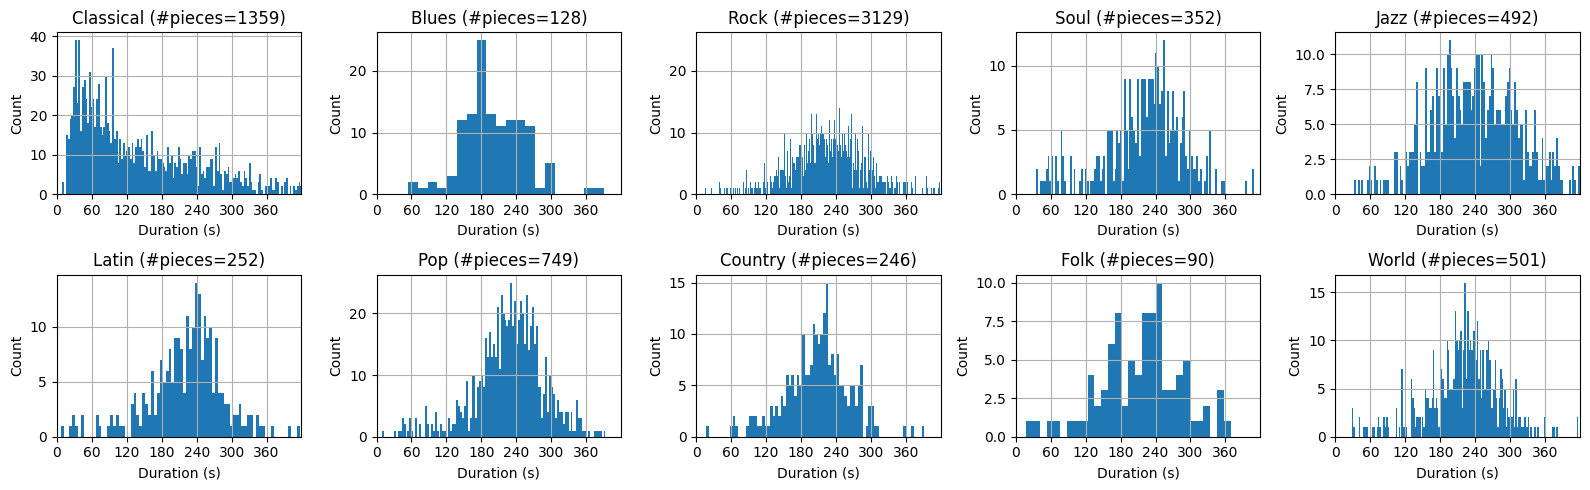

In [6]:
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=False, layout='tight')

for i, genre in enumerate(genres_of_interest):
    path_genre = os.path.join(path_data, genre)
    df = pd.read_csv(f'{path_genre}.csv')
    df['duration'].plot.hist(
        bins=df.shape[0]//3, ax=axs[i//5,i%5], xlim=[0, 7*60], grid=True, xticks=[i*60 for i in range(7)],
        xlabel='Duration (s)', ylabel='Count', title=f'{genre} (#pieces={df.shape[0]})')

Prototype filters and visualize multiple variables with overlapping histograms.

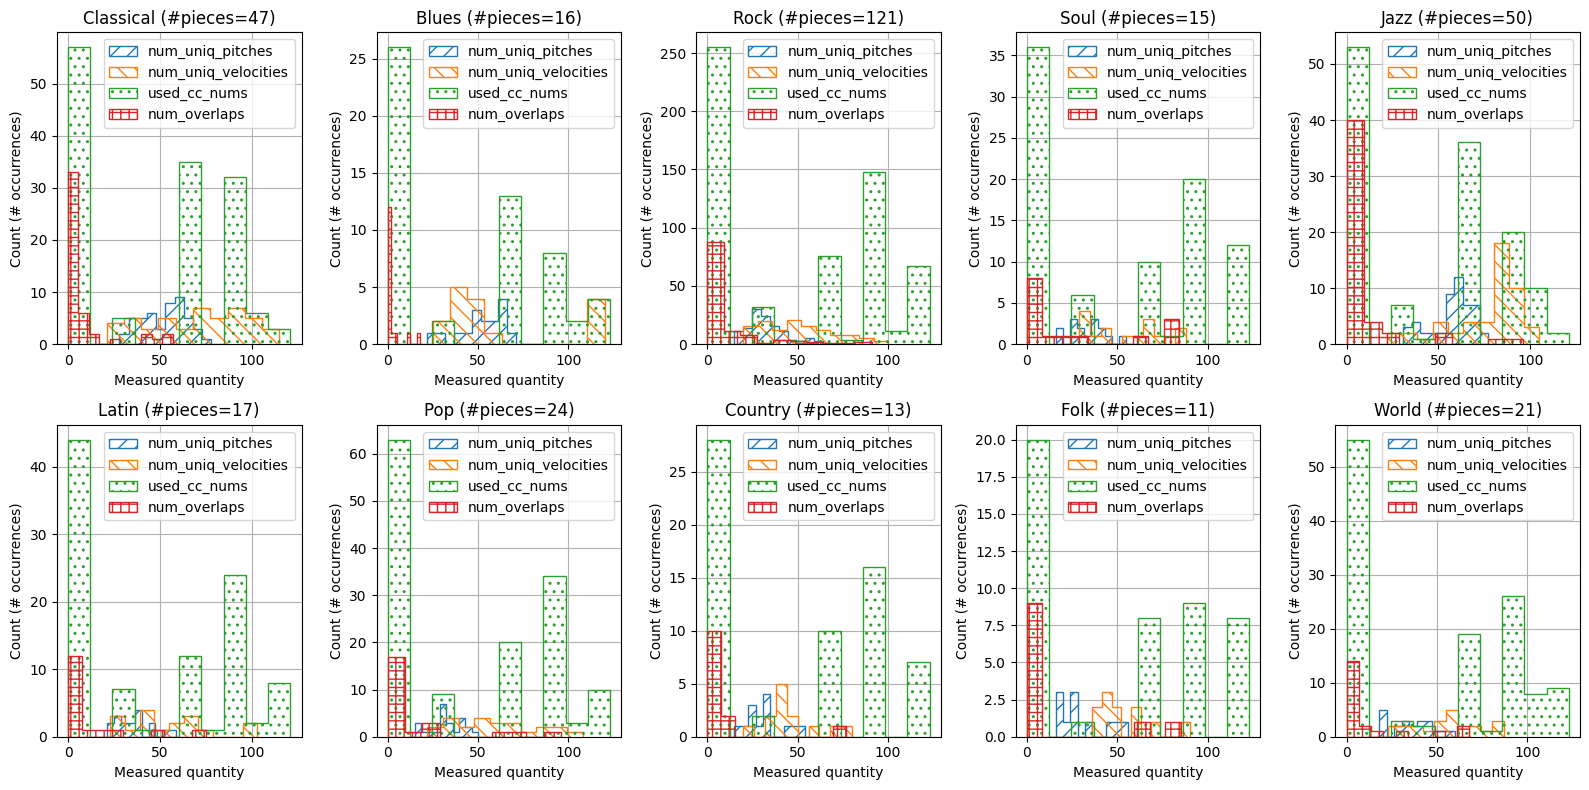

In [53]:
fig, axs = plt.subplots(2, 5, figsize=(16, 8), sharex=False, sharey=False, layout='tight')

for i, genre in enumerate(genres_of_interest):
    path_genre = os.path.join(path_data, genre)
    df = pd.read_csv(f'{path_genre}.csv')
    df = df[(df['duration'] >= 2*60) & (df['duration'] <= 4*60)]
    df = df[df['gaps_max'] <= 5]
    df = df[df['num_uniq_velocities'] >= 20]
    df = df[df['num_uniq_pitches'] >= 15]
    df = df[df['num_overlaps'] <= 100] # maybe relax this one later
    df = df[df['num_uniq_cc_nums'] <= 20]
    from ast import literal_eval
    df = df[df['instr_programs'].apply(lambda x: np.all(np.unique(literal_eval(x)) < 8))] # only piano instruments
    # df = df[df['num_notes'].apply(lambda x: sum(literal_eval(x)) < 10000)] # at least X note events
    df = df[df['num_bends'].apply(lambda x: sum(literal_eval(x)) == 0)] # no pitch bends
    # df = df[df['num_ccs'].apply(lambda x: sum(literal_eval(x)) == 0)] # not too many CC events?
    if genre != 'Folk':
        df = df[df['mean_polyphony'] >= 3.0] # empirically determined threhsold to filter out "low-quality" pieces

    df['num_uniq_pitches'].plot.hist(
        ax=axs[i//5,i%5], grid=True, log=False, label='num_uniq_pitches', histtype='step', hatch='//',
        xlabel='Measured quantity', ylabel='Count (# occurrences)', title=f'{genre} (#pieces={df.shape[0]})')
    df['num_uniq_velocities'].plot.hist(
        ax=axs[i//5,i%5], grid=True, log=False, label='num_uniq_velocities', histtype='step', hatch='\\\\',
        xlabel='Measured quantity', ylabel='Count (# occurrences)', title=f'{genre} (#pieces={df.shape[0]})')
    pd.Series(df['uniq_cc_nums'].apply(lambda x: literal_eval(x)).sum()).plot.hist(
        ax=axs[i//5,i%5], grid=True, log=False, label='used_cc_nums', histtype='step', hatch='..',
        xlabel='Measured quantity', ylabel='Count (# occurrences)', title=f'{genre} (#pieces={df.shape[0]})')
    df['num_overlaps'].plot.hist(
        ax=axs[i//5,i%5], grid=True, log=False, label='num_overlaps', histtype='step', hatch='++',
        xlabel='Measured quantity', ylabel='Count (# occurrences)', title=f'{genre} (#pieces={df.shape[0]})')
    axs[i//5,i%5].legend(loc='upper right')

Visualize the piece duration distribution per genre **after filtering**.

In [46]:
# hardcoded blacklist for reproducibility -- weird pieces with spike-y velocity histograms and low representativeness of their genre -- excluded
blacklist = [
    '../data/apm/Soul/Classic Soul/The Elgins/In The Midnight Hour.mid',
    '../data/apm/Soul/Chicago Soul/The Esquires/Groovin.mid',
    '../data/apm/Soul/Soul/Aaron Neville/Jesus Love Me.mid',
    '../data/apm/Pop/Classic Italian Pop/Edoardo Vianello/Abbronzatissima.mid',
    '../data/apm/Country/Country Gospel/Cristy Lane/Silent Night.mid',
    '../data/apm/Rock/Dance Rock/George Michael/Last Christmas.mid',
    '../data/apm/Rock/Classic Finnish Rock/Heikki Silvennoinen/Down Hearted Man.mid',
    '../data/apm/Rock/Australian Rock/Graeme Connors/Id Rather Be Sorry.mid',
    '../data/apm/Rock/Neo Mellow/Jasmine/Per Non Perderti.mid',
    '../data/apm/Rock/Modern Rock/The Band/As Long As You Love Me.mid'
    ]

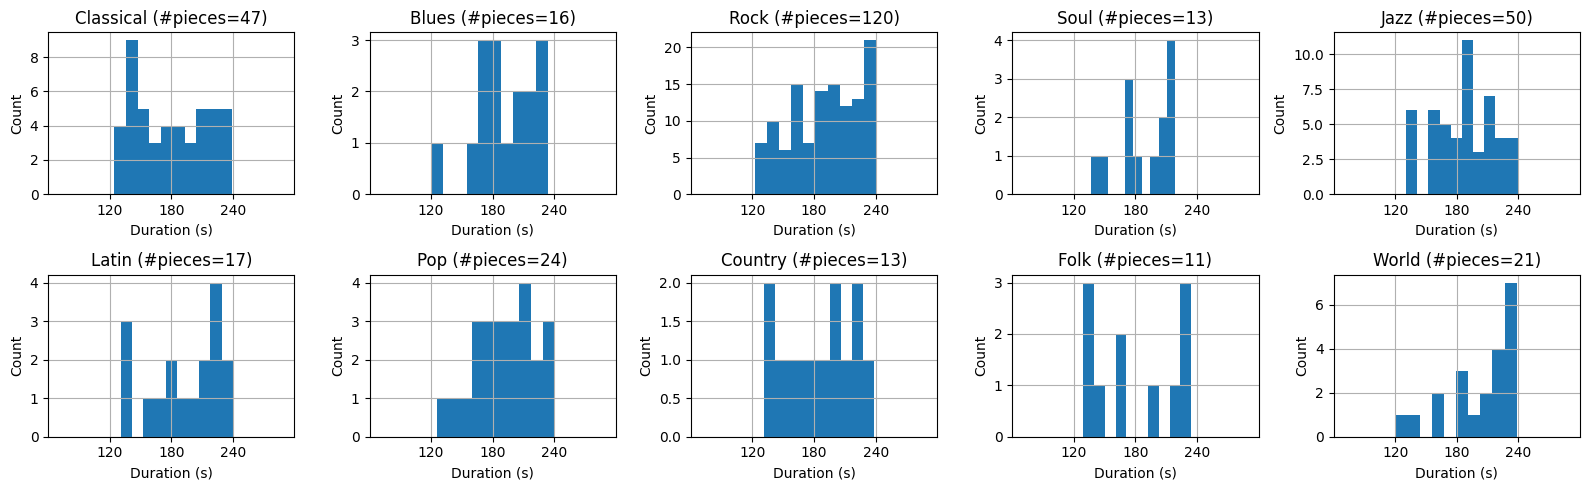

In [54]:
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=False, layout='tight')

for i, genre in enumerate(genres_of_interest):
    path_genre = os.path.join(path_data, genre)
    df = pd.read_csv(f'{path_genre}.csv')
    df = df[(df['duration'] >= 2*60) & (df['duration'] <= 4*60)]
    df = df[df['gaps_max'] <= 5]
    df = df[df['num_uniq_velocities'] >= 20]
    df = df[df['num_uniq_pitches'] >= 15]
    df = df[df['num_overlaps'] <= 100] # maybe relax this one later
    df = df[df['num_uniq_cc_nums'] <= 20]
    df = df[df['instr_programs'].apply(lambda x: np.all(np.unique(literal_eval(x)) < 8))] # only piano instruments
    df = df[df['num_bends'].apply(lambda x: sum(literal_eval(x)) == 0)] # no pitch bends
    if genre != 'Folk':
        df = df[df['mean_polyphony'] >= 3.0]
    df = df[df['path'].apply(lambda path: path not in blacklist)]
    
    df['duration'].plot.hist(
        ax=axs[i//5,i%5], xlim=[1*60, 5*60], grid=True, xticks=[i*60 for i in range(2,4+1,1)],
        xlabel='Duration (s)', ylabel='Count', title=f'{genre} (#pieces={df.shape[0]})')

Next: for each genre, filter out pieces of desired interval and `random.sample()` N pieces per genre.

In [55]:
!mkdir -p ../data/1_genre

n_pieces_per_genre = 10

df_meta = pd.DataFrame()
for genre in genres_of_interest:
    path_genre = os.path.join(path_data, genre)
    df_all = pd.read_csv(f'{path_genre}.csv')
    df = df_all.copy()
    df = df[(df['duration'] >= 2*60) & (df['duration'] <= 4*60)]
    df = df[df['gaps_max'] <= 5]
    df = df[df['num_uniq_velocities'] >= 20]
    df = df[df['num_uniq_pitches'] >= 15]
    df = df[df['num_overlaps'] <= 100] # maybe relax this one later
    df = df[df['num_uniq_cc_nums'] <= 20]
    df = df[df['instr_programs'].apply(lambda x: np.all(np.unique(literal_eval(x)) < 8))] # only piano instruments
    df = df[df['num_bends'].apply(lambda x: sum(literal_eval(x)) == 0)] # no pitch bends
    if genre != 'Folk': # can't afford to drop any more Folk pieces, need 10/11
        df = df[df['mean_polyphony'] >= 3.0]
    if blacklist:
        df = df[df['path'].apply(lambda path: path not in blacklist)]

    n_all = df_all.shape[0]
    n_filtered = df.shape[0]
    n_frac = n_filtered/n_all
    print(f'{genre}: {n_filtered}/{n_all} pieces ({n_frac*100:.2f}%) left after filtering. Selecting {n_pieces_per_genre} randomly.')

    random.seed(0)
    selected_pieces = random.sample(df.to_dict('records'), k=n_pieces_per_genre)
    for i, piece in enumerate(selected_pieces):
        midi = pm.PrettyMIDI(piece['path'])
        piece_name = piece['path'].split('/')[-1].split('.')[0]
        filename = f'{genre}_{i+1:02d}'

        df_meta_record = {
            'genre': genre,
            'duration [s]': piece['duration'],
            'tempo [BPM]': midi.estimate_tempo(),
            'time signature(s)': [f'{tsc.numerator}/{tsc.denominator}' for tsc in midi.time_signature_changes],
            '# instruments': len(midi.instruments),
            'instruments': [inst.program for inst in midi.instruments],
            '# notes per inst': [len(inst.notes) for inst in midi.instruments],
            '# notes': sum([len(inst.notes) for inst in midi.instruments]),
            '# CCs per inst': [len(inst.control_changes) for inst in midi.instruments],
            '# CCs': sum([len(inst.control_changes) for inst in midi.instruments]),
            '# CCs by number': dict(zip(*np.unique(
                list(itertools.chain.from_iterable([[cc.number for cc in inst.control_changes] for inst in midi.instruments])), return_counts=True))),
            '# unique pitches': piece['num_uniq_pitches'],
            '# unique velocities': piece['num_uniq_velocities'],
            'longest gap [s]': piece['gaps_max'],
            'total gap time [s]': piece['gaps_sum'],
            'piece': piece_name,
            'file name': filename,
            'original file': piece['path'],
        }
        df_meta = df_meta._append(df_meta_record, ignore_index=True)
        
        # merge instruments into one
        if len(midi.instruments) > 1:
            for inst in midi.instruments[1:]:
                midi.instruments[0].notes += inst.notes
            midi.instruments = [midi.instruments[0]]
        midi.remove_invalid_notes()
        midi.instruments[0].program = 0 # grand piano
        overlaps = detect_overlapping_notes_in_pretty_midi_note_array(midi.instruments[0].notes, verbose=False)
        og_len_overlaps = len(overlaps)
        if len(overlaps) > 0:
            while True:
                overlaps = detect_overlapping_notes_in_pretty_midi_note_array(midi.instruments[0].notes)
                if len(overlaps) == 0:
                    break
                # handle overlapping notes by readjusting their start and end times
                for overlap in overlaps:
                    n1, n2, dur = overlap
                    assert n2.start > n1.start, f'{n1.start} > {n2.start}'
                    n1_end = n1.end
                    n1.end = n2.start
                    n2.end = max(n1_end, n2.end)
            assert len(overlaps) == 0, f'Piece {filename} still has {len(overlaps)} overlaps.'

        midi.lyrics.append(pm.Lyric(piece_name, 0))
        # midi.write(f'../data/1_genre/{filename}.mid')

df_meta.to_csv('../data/1_genre_meta_raw.csv', index=False)
print(f"total duration is {df_meta['duration [s]'].sum() / 60 / 60:.4f} hours")
df_meta

Classical: 47/1359 pieces (3.46%) left after filtering. Selecting 10 randomly.
Blues: 16/128 pieces (12.50%) left after filtering. Selecting 10 randomly.
Rock: 120/3129 pieces (3.84%) left after filtering. Selecting 10 randomly.
Soul: 13/352 pieces (3.69%) left after filtering. Selecting 10 randomly.
Jazz: 50/492 pieces (10.16%) left after filtering. Selecting 10 randomly.
Latin: 17/252 pieces (6.75%) left after filtering. Selecting 10 randomly.
Pop: 24/749 pieces (3.20%) left after filtering. Selecting 10 randomly.
Country: 13/246 pieces (5.28%) left after filtering. Selecting 10 randomly.
Folk: 11/90 pieces (12.22%) left after filtering. Selecting 10 randomly.
World: 21/501 pieces (4.19%) left after filtering. Selecting 10 randomly.
total duration is 5.2474 hours


,genre,duration [s],tempo [BPM],time signature(s),# instruments,instruments,# notes per inst,# notes,# CCs per inst,# CCs,# CCs by number,# unique pitches,# unique velocities,longest gap [s],total gap time [s],piece,file name,original file
0,Classical,177.941982,217.961632,"[4/4, 3/4, 2/4, 3/4, 3/4, 2/4, 3/4]",2,"[0, 0]","[756, 723]",1479,"[34, 4]",38,"{0: 2, 10: 3, 32: 2, 64: 28, 91: 3}",58,102,3.452344,29.924636,Lyric Pieces_ Bk V Op 54 V Scherzo,Classical_01,../data/apm/Classical/Classical/Leif Ove Andsn...
1,Classical,163.630445,204.028594,[4/4],1,[0],[2232],2232,[266],266,"{7: 2, 10: 2, 64: 261, 91: 1}",53,70,0.352112,31.102623,The Seasons Op 37b IX Septembre (La chasse),Classical_02,../data/apm/Classical/Classical Performance/Mi...
2,Classical,234.666784,104.999948,"[1/4, 3/4, 2/4, 1/4, 3/4, 2/4, 1/4, 3/4, 2/4, ...",1,[0],[1002],1002,[102],102,"{7: 55, 10: 1, 64: 44, 91: 1, 93: 1}",41,21,2.666668,18.090287,Storia DAmore (Live),Classical_03,../data/apm/Classical/Operatic Pop/Sarah Brigh...
3,Classical,203.047547,136.768142,[6/8],1,[4],[647],647,[79],79,"{1: 2, 7: 4, 64: 72, 91: 1}",35,24,0.016667,2.480023,Silent Night (Karaoke Version),Classical_04,../data/apm/Classical/Operatic Pop/Mark Masri/...
4,Classical,154.037939,264.850861,[4/4],1,[0],[2082],2082,[173],173,{64: 173},65,103,0.573529,4.776676,Etude In C Minor,Classical_05,../data/apm/Classical/Ballroom/Roger Williams/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,World,185.390685,151.135453,[4/4],1,[0],[463],463,[3],3,"{0: 1, 7: 1, 91: 1}",19,58,2.857140,8.140367,Que lAmour Est Violent,World_06,../data/apm/World/Chanson/Garou/Que lAmour Est...
96,World,227.525000,116.814159,[4/4],2,"[1, 5]","[526, 285]",811,"[91, 9]",100,"{0: 2, 1: 2, 6: 2, 7: 2, 10: 2, 64: 82, 91: 2,...",36,55,3.000000,12.625000,JMe Sens Mieux Quand JMe Sens Mal,World_07,../data/apm/World/Chanson/Eddy Mitchell/JMe Se...
97,World,120.346319,98.400177,[2/4],1,[0],[725],725,[170],170,"{7: 2, 10: 2, 64: 162, 91: 2, 121: 2}",40,56,0.000000,0.000000,Jag bor på en stjärna (Pomp And Circumstance),World_08,../data/apm/World/Classic Swedish Pop/Sanna Ni...
98,World,229.869900,105.478229,"[4/4, 5/4, 4/4, 5/4, 4/4, 2/4, 4/4, 5/4, 4/4]",1,[0],[978],978,[397],397,"{6: 1, 7: 1, 10: 1, 11: 1, 38: 1, 64: 387, 91:...",39,48,3.116880,39.902558,La Vie Ne MApprend Rien,World_09,../data/apm/World/Chanson/Daniel Balavoine/La ...


Curate metadata CSV

In [ ]:
# load data from CSV file
df = pd.read_csv('../data/1_genre_meta_raw.csv')

# select only specific columns from the DataFrame in a new ordering
df = df[['file name', 'piece', 'genre', 'original file'] + ['duration [s]', 'longest gap [s]', 'total gap time [s]', 'tempo [BPM]', '# notes', '# unique pitches', '# unique velocities']]

# rename columns
df.columns = ['mds_file', 'title', 'genre', 'path_in_adl_piano_midi', 'duration_sec', 'longest_gap_sec', 'total_gap_sec', 'tempo_bpm', 'num_notes', 'num_unique_pitches', 'num_unique_velocities']

# remove the first occurrence of '../data/amp/' from each string in the 'path_in_adl_piano_midi' column
df['path_in_adl_piano_midi'] = df['path_in_adl_piano_midi'].str.replace('../data/apm/', '', n=1)

# df.to_csv('../data/metadata/1_genre_meta.csv', index=False)
df

,mds_file,title,genre,path_in_adl_piano_midi,duration_sec,longest_gap_sec,total_gap_sec,tempo_bpm,num_notes,num_unique_pitches,num_unique_velocities
0,Classical_01,Lyric Pieces_ Bk V Op 54 V Scherzo,Classical,Classical/Classical/Leif Ove Andsnes/Lyric Pie...,177.941982,3.452344,29.924636,217.961632,1479,58,102
1,Classical_02,The Seasons Op 37b IX Septembre (La chasse),Classical,Classical/Classical Performance/Mikhail Pletne...,163.630445,0.352112,31.102623,204.028594,2232,53,70
2,Classical_03,Storia DAmore (Live),Classical,Classical/Operatic Pop/Sarah Brightman/Storia ...,234.666784,2.666668,18.090287,104.999948,1002,41,21
3,Classical_04,Silent Night (Karaoke Version),Classical,Classical/Operatic Pop/Mark Masri/Silent Night...,203.047547,0.016667,2.480023,136.768142,647,35,24
4,Classical_05,Etude In C Minor,Classical,Classical/Ballroom/Roger Williams/Etude In C M...,154.037939,0.573529,4.776676,264.850861,2082,65,103
...,...,...,...,...,...,...,...,...,...,...,...
95,World_06,Que lAmour Est Violent,World,World/Chanson/Garou/Que lAmour Est Violent.mid,185.390685,2.857140,8.140367,151.135453,463,19,58
96,World_07,JMe Sens Mieux Quand JMe Sens Mal,World,World/Chanson/Eddy Mitchell/JMe Sens Mieux Qua...,227.525000,3.000000,12.625000,116.814159,811,36,55
97,World_08,Jag bor på en stjärna (Pomp And Circumstance),World,World/Classic Swedish Pop/Sanna Nielsen/Jag bo...,120.346319,0.000000,0.000000,98.400177,725,40,56
98,World_09,La Vie Ne MApprend Rien,World,World/Chanson/Daniel Balavoine/La Vie Ne MAppr...,229.869900,3.116880,39.902558,105.478229,978,39,48


## Velocity/Dynamics Analysis

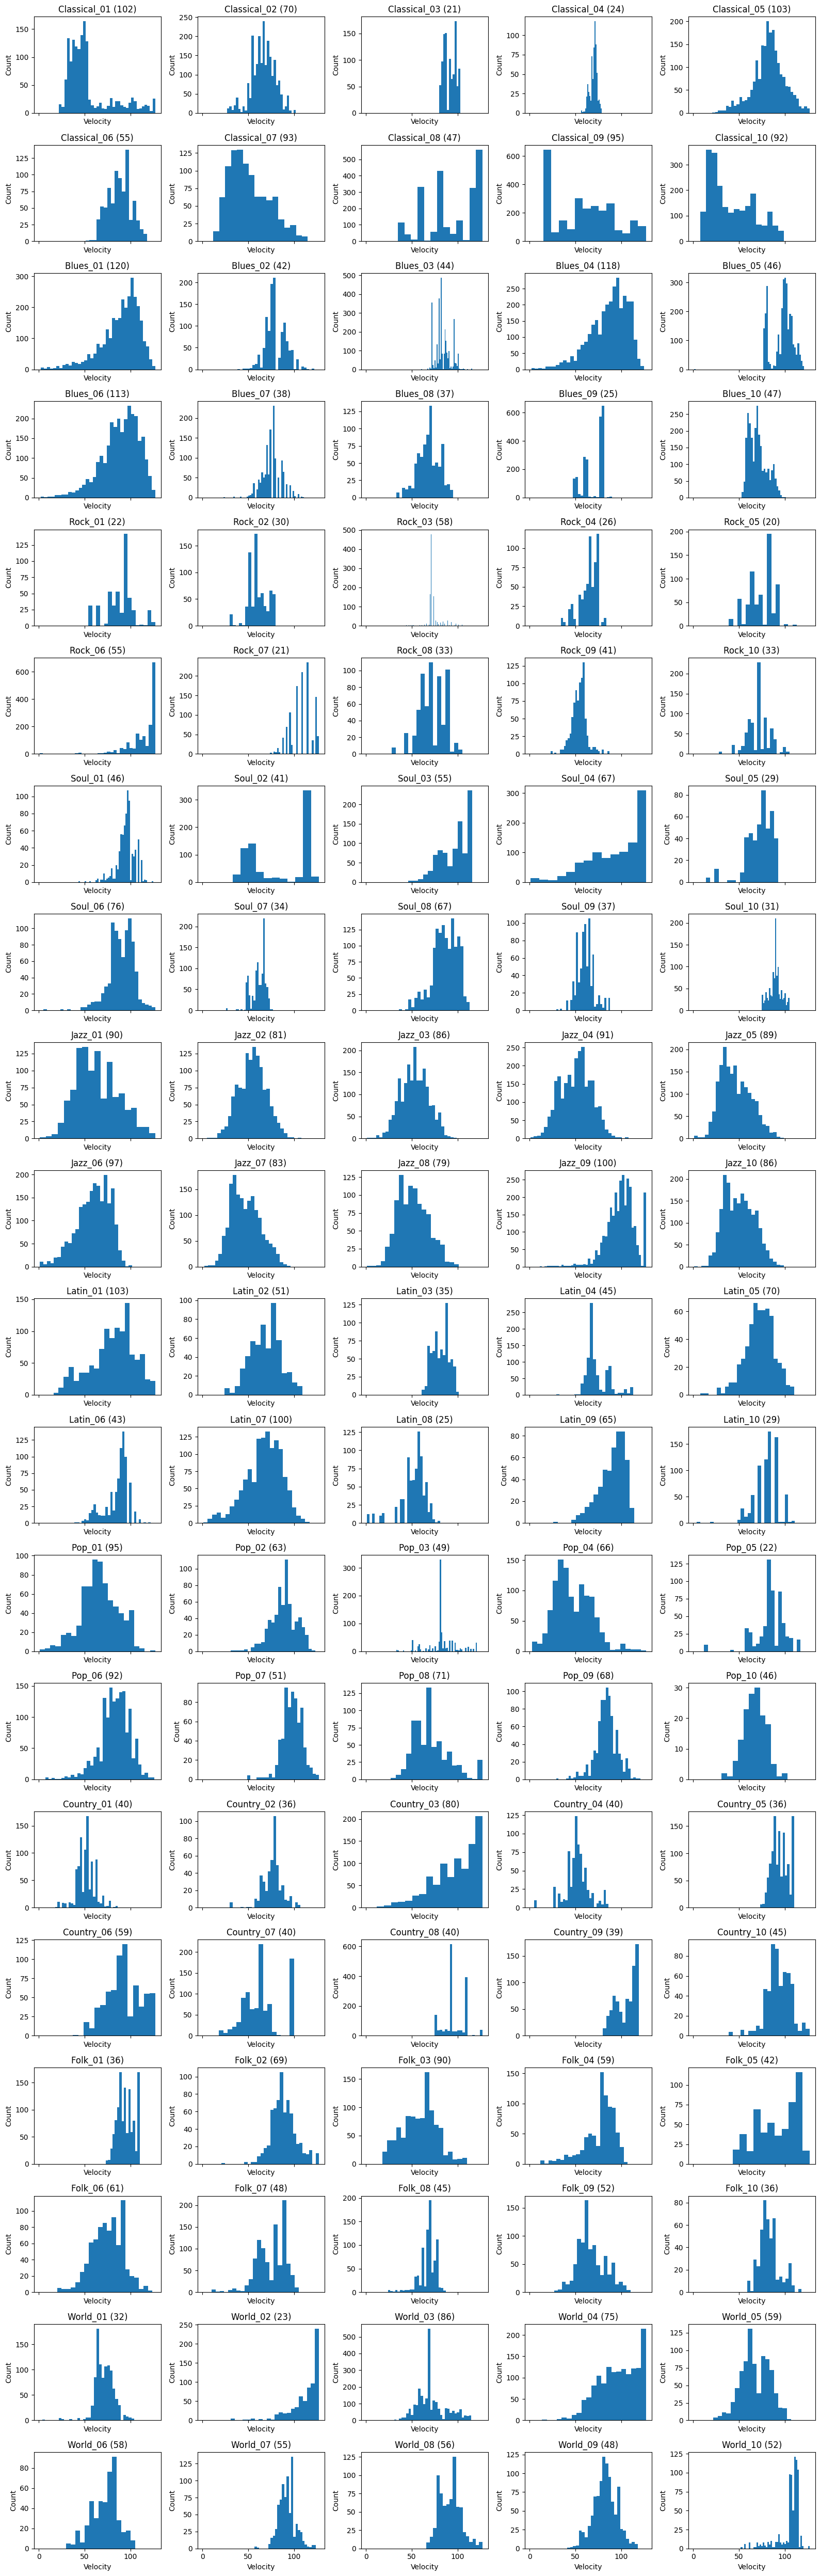

In [56]:
df_meta = pd.read_csv('../data/1_genre_meta_raw.csv')

fig, axs = plt.subplots(2*10, 5, figsize=(16, 10*5), sharex=True, sharey=False, layout='tight')
avg_velocities = {}
for i, filename in enumerate(df_meta['file name']):
    midi = pm.PrettyMIDI(f'../data/1_genre/{filename}.mid')
    velocities = []
    for note in midi.instruments[0].notes:
        velocities.append(note.velocity)
    axs[i//5,i%5].hist(velocities, bins='auto')#, ax=axs[i//5,i%5])
    axs[i//5,i%5].set_xlabel('Velocity')
    axs[i//5,i%5].set_ylabel('Count')
    axs[i//5,i%5].set_title(f'{filename} ({len(np.unique(velocities))})')

    avg_velocities[filename] = np.mean(velocities)
fig.savefig('../velocities.pdf')

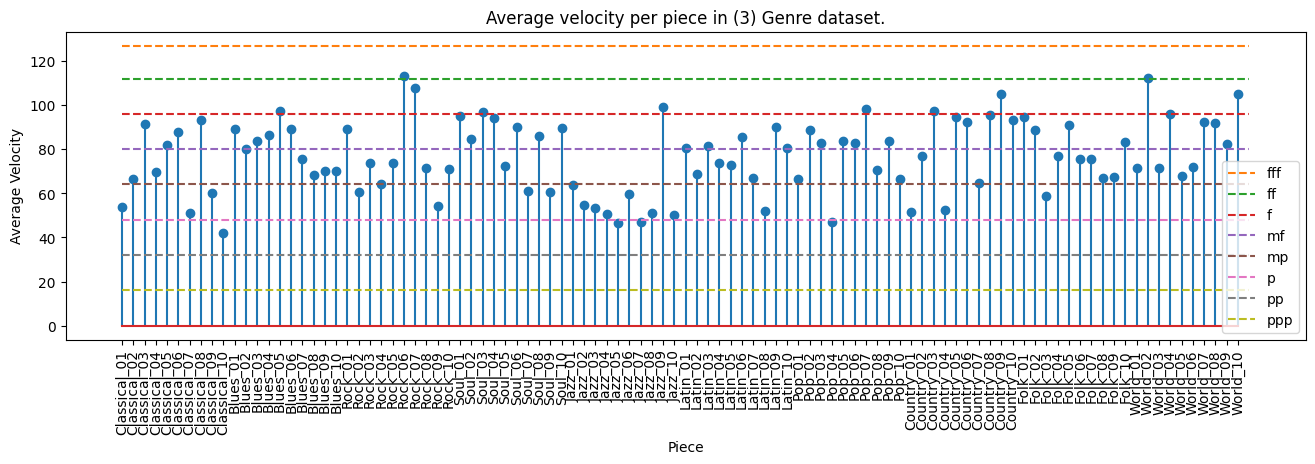

In [64]:
fig = plt.figure(figsize=(16, 4))
plt.stem(avg_velocities.values())
plt.xticks(range(len(avg_velocities)), avg_velocities.keys(), rotation=90);
plt.title('Average velocity per piece in (3) Genre dataset.')
plt.xlabel('Piece');
plt.ylabel('Average Velocity')
c = 'tab:orange'
plt.hlines(127, 0, len(avg_velocities), colors='tab:orange', linestyles='dashed', label='fff')
plt.hlines(112, 0, len(avg_velocities), colors='tab:green', linestyles='dashed', label='ff')
plt.hlines(96, 0, len(avg_velocities), colors='tab:red', linestyles='dashed', label='f')
plt.hlines(80, 0, len(avg_velocities), colors='tab:purple', linestyles='dashed', label='mf')
plt.hlines(64, 0, len(avg_velocities), colors='tab:brown', linestyles='dashed', label='mp')
plt.hlines(48, 0, len(avg_velocities), colors='tab:pink', linestyles='dashed', label='p')
plt.hlines(32, 0, len(avg_velocities), colors='tab:grey', linestyles='dashed', label='pp')
plt.hlines(16, 0, len(avg_velocities), colors='tab:olive', linestyles='dashed', label='ppp')
plt.legend();
fig.savefig('../velocities_avg.pdf')

## Polyphony Analysis

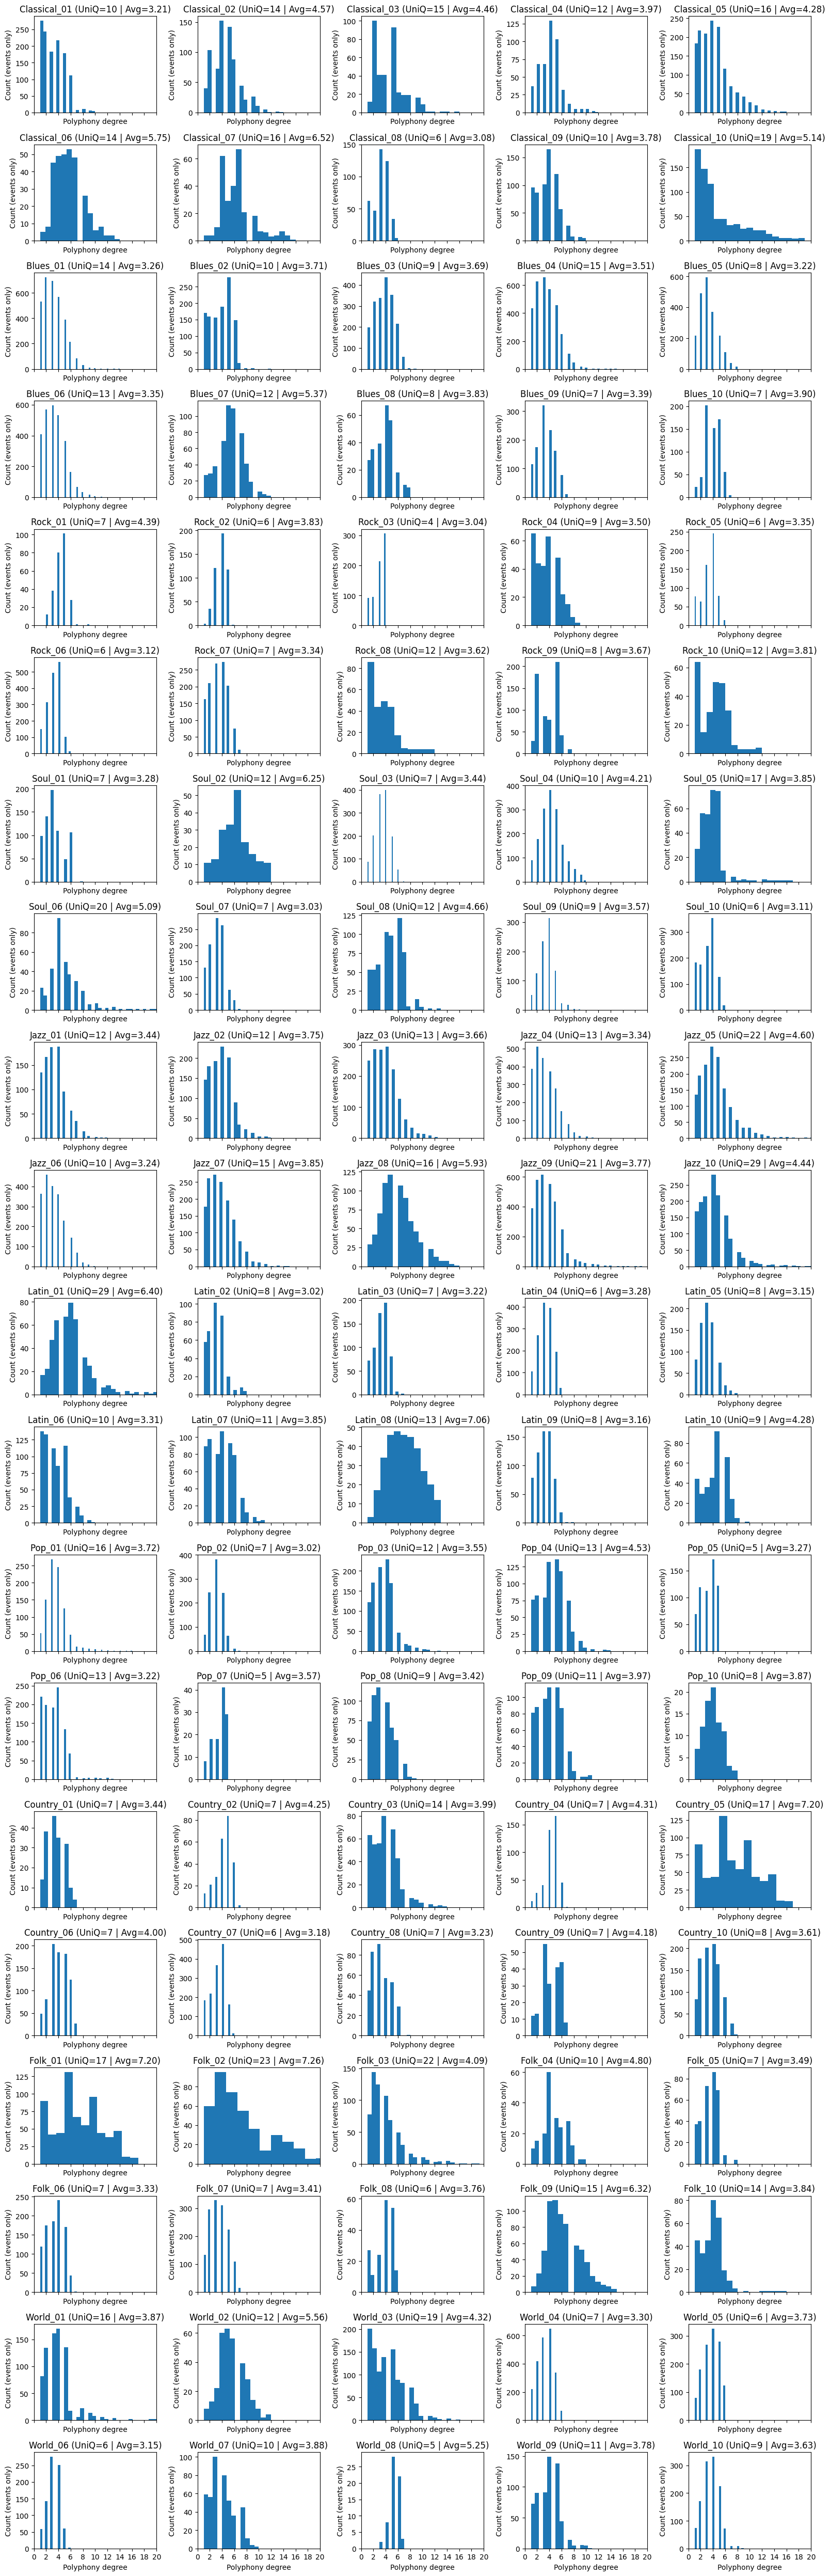

In [58]:
df_meta = pd.read_csv('../data/1_genre_meta_raw.csv')

fig, axs = plt.subplots(2*10, 5, figsize=(16, 10*5), sharex=True, sharey=False, layout='tight')
avg_polyphonies = {}
for i, filename in enumerate(df_meta['file name']):
    midi = pm.PrettyMIDI(f'../data/1_genre/{filename}.mid')
    polyphonies = get_polyphony_degrees(midi.instruments[0], fs=100, events_only=True)
    axs[i//5,i%5].hist(polyphonies, bins='auto')
    axs[i//5,i%5].set_xlabel('Polyphony degree')
    axs[i//5,i%5].set_ylabel('Count (events only)')
    axs[i//5,i%5].set_xlim(0, 20)
    axs[i//5,i%5].set_xticks(np.arange(0, 20+1, 2))
    axs[i//5,i%5].set_title(f'{filename} (UniQ={len(np.unique(polyphonies))} | Avg={np.mean(polyphonies):.2f})')
    
    avg_polyphonies[filename] = np.mean(polyphonies)
fig.savefig('../polyphonies.pdf')

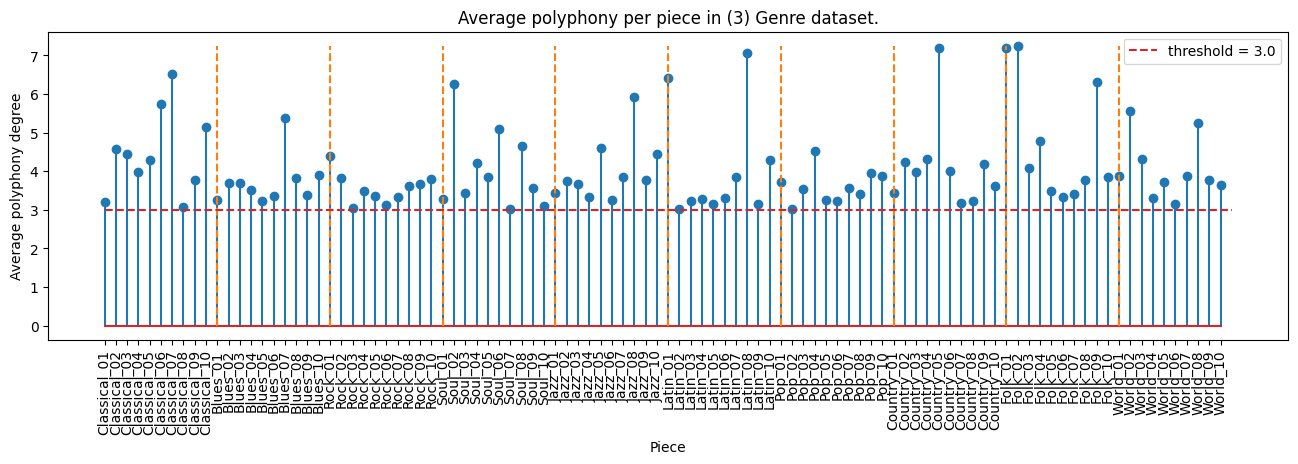

In [63]:
fig = plt.figure(figsize=(16, 4))
plt.stem(avg_polyphonies.values())
plt.xticks(range(len(avg_polyphonies)), avg_polyphonies.keys(), rotation=90);
plt.title('Average polyphony per piece in (3) Genre dataset.')
plt.xlabel('Piece');
plt.ylabel('Average polyphony degree');

thr = 3.

for i in range(1, 10):
    plt.vlines(i*10, 0, max(avg_polyphonies.values()), colors='tab:orange', linestyles='dashed')
plt.hlines(thr, 0, len(avg_polyphonies), colors='tab:red', linestyles='dashed', label=f'threshold = {thr}')
plt.legend();

fig.savefig('../polyphonies_avg.pdf')